In [49]:
from opacus.accountants import RDPAccountant
import matplotlib.pyplot as plt
from matplotlib import cm

In [55]:
DELTA = 1e-5
SAMPLE_RATE=4096/50000
NOISE=3
MAX_EPS=3

In [56]:
DELTA

1e-05

/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_49887/4162358863.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", len(NOISE_MULTIPLIERS))


sigma=1, nb_steps=11
sigma=2, nb_steps=207
sigma=3, nb_steps=541


/Users/lisaschmidt/Documents/GitHub/privacy-preserving-data-analytics/src/tan/env/lib/python3.12/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


sigma=4, nb_steps=1009
sigma=5, nb_steps=1610
sigma=6, nb_steps=2345


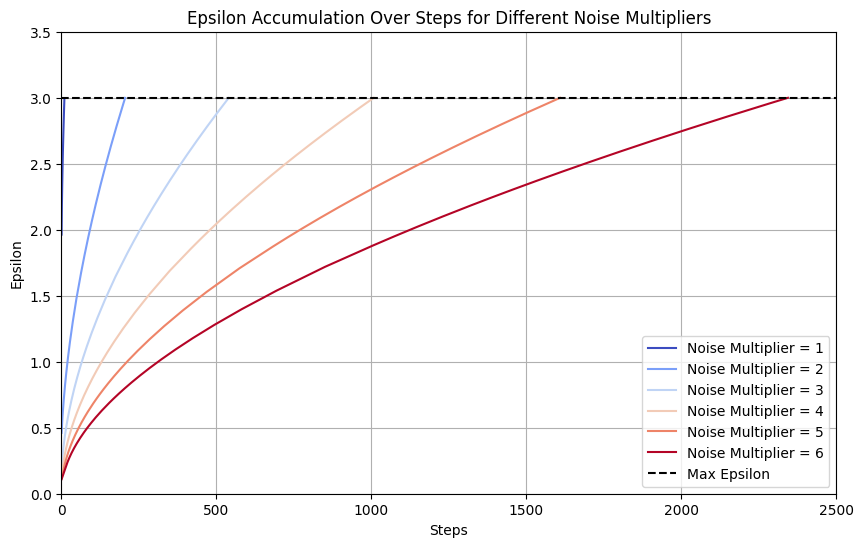

<Figure size 640x480 with 0 Axes>

In [62]:
fig = plt.figure(figsize=(10, 6))
NOISE_MULTIPLIERS = [1, 2, 3, 4, 5, 6]
MAX_STEPS = 3000

colormap = cm.get_cmap("coolwarm", len(NOISE_MULTIPLIERS))
colors = [colormap(i) for i in range(len(NOISE_MULTIPLIERS))]

for idx, noise in enumerate(NOISE_MULTIPLIERS):
    acc = RDPAccountant()
    epsilons = []
    steps = []
    
    for step in range(1, MAX_STEPS + 1):
        acc.step(noise_multiplier=noise, sample_rate=SAMPLE_RATE)
        epsilon = acc.get_epsilon(delta=DELTA)
        
        # Stop simulation if epsilon exceeds MAX_EPS
        if epsilon > MAX_EPS:
            break

        epsilons.append(epsilon)
        steps.append(step)
    
    plt.plot(steps, epsilons, label=f"Noise Multiplier = {noise}", color=colors[idx])
    print(f"sigma={noise}, nb_steps={step}")

plt.title("Epsilon Accumulation Over Steps for Different Noise Multipliers")
plt.xlabel("Steps")
plt.ylabel("Epsilon")
plt.xlim(0, 2500)
plt.ylim(0, 3.5)
plt.axhline(MAX_EPS, color="black", linestyle="--", label="Max Epsilon")
plt.legend()
plt.grid()
plt.show()
plt.savefig("epsilon_noise_simulation.pdf")

In [63]:
fig.savefig("epsilon_noise_simulation.pdf")

In [65]:
2**5

32

/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_49887/673490769.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", len(batchsizes))
/Users/lisaschmidt/Documents/GitHub/privacy-preserving-data-analytics/src/tan/env/lib/python3.12/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


sigma=0.0128, nb_steps=5000
sigma=0.0256, nb_steps=5000
sigma=0.0512, nb_steps=4147
sigma=0.1024, nb_steps=1027
sigma=0.2048, nb_steps=253


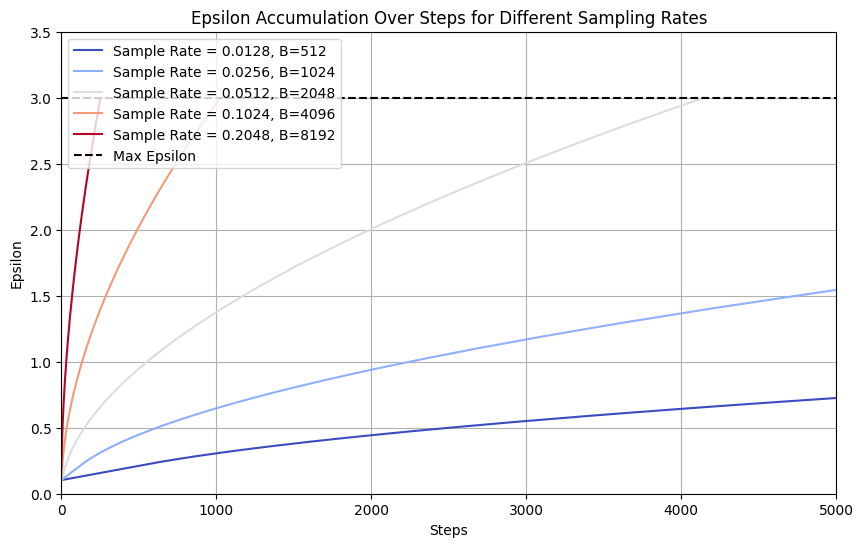

In [ ]:
fig = plt.figure(figsize=(10, 6))

batchsizes = [512, 1024, 2048, 4096, 8192]
SAMPLES = 40000
MAX_STEPS = 5000
NOISE=5

colormap = cm.get_cmap("coolwarm", len(batchsizes))
colors = [colormap(i) for i in range(len(batchsizes))]

for idx, batchsize in enumerate(batchsizes):
    rate = batchsize/SAMPLES
    acc = RDPAccountant()
    epsilons = []
    steps = []
    
    for step in range(1, MAX_STEPS + 1):
        acc.step(noise_multiplier=NOISE, sample_rate=rate)
        epsilon = acc.get_epsilon(delta=DELTA)
        
        # Stop simulation if epsilon exceeds MAX_EPS
        if epsilon > MAX_EPS:
            break

        epsilons.append(epsilon)
        steps.append(step)
    
    plt.plot(steps, epsilons, label=f"Sample Rate = {rate}, B={batchsize}", color=colors[idx])
    print(f"sigma={rate}, nb_steps={step}")

plt.title("Epsilon Accumulation Over Steps for Different Sampling Rates")
plt.xlabel("Steps")
plt.ylabel("Epsilon")
plt.xlim(0, 5000)
plt.ylim(0, 3.5)
plt.axhline(MAX_EPS, color="black", linestyle="--", label="Max Epsilon")
plt.legend()
plt.grid()
plt.show()
fig.savefig("epsilon_sampling_simulation.pdf")
